In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import Normalizer
from scipy.stats import skew

pd.options.display.max_columns = 500

Снова потренируемся в предсказании цен на недвижимость из [очередного датасета с каггла](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/)! В качестве основной метрики для валидации моделей будем использовать, как и ранее, `MSLE`.

P.S. в данной домашней работе при построении любых моделей, использующих недетерменированные элементы (как бутстрап), в алгоритме указывайте параметр `random_state = 1` для воспроизводимости результатов.

In [2]:
df = (
    pd.read_csv('train_houses_reg.csv')
    .drop('Id', axis=1)
)

df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,

In [3]:
### Разделим выборку на объекты-таргеты

Y = df['SalePrice']
X = df.drop(columns=['SalePrice'])

### Логарифмируем таргет для будущей оптимизации
### MSLE через MSE

log_target = np.log1p(Y)

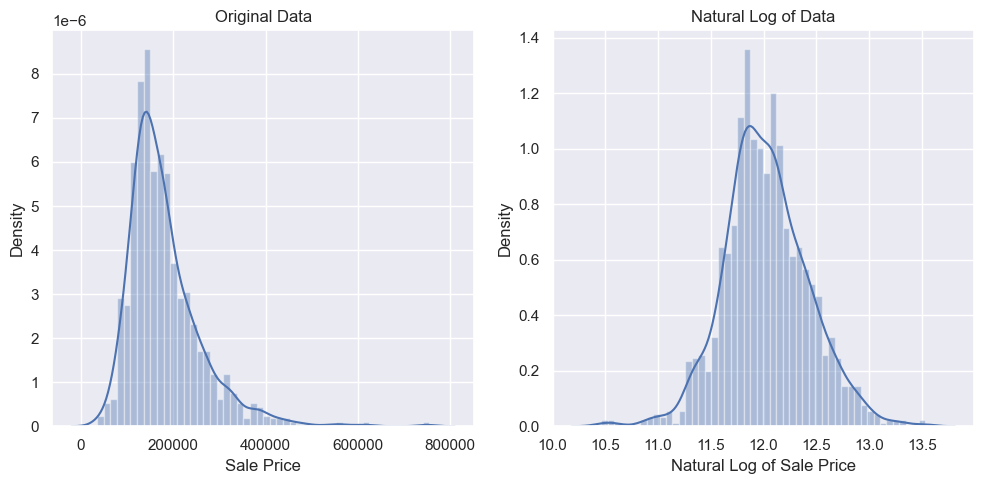

In [4]:
### Это позволяет получить нормальное распределение таргета
### Важно, например, для построения корректной
### С точки зрения статистических свойств
### Линейной модели.
### Хотя здесь мы будем строить ансамбли деревьев,
### И это не особо интересно.

sns.set(rc={'figure.figsize':(15,10)})

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.distplot(Y, bins=50)
plt.title('Original Data')
plt.xlabel('Sale Price')

plt.subplot(1,2,2)
sns.distplot(log_target, bins=50)
plt.title('Natural Log of Data')
plt.xlabel('Natural Log of Sale Price')
plt.tight_layout()

### В начале поработаем с пропусками!

Если в какой-либо колонке оказывается достаточно много пропусков, обычно советуют от них избавляться. Мотивировано это тем, что в таких фичах мы можем наблюдать серьезный недостаток информативности, а заполнение пропусков может лишь внести лишнего шума в данные.

Избавьтесь от всех колонок, в которых пропусков оказывается больше 15%. (1б)

In [5]:
X = X.dropna(axis='columns', thresh=0.85*X.shape[0])

Вещественные колонки заполните медианным значением по фиче, а категориальные - самой популярной по колонке категорией. (2б)

Заметьте, что колонки `MoSold`, `YrSold`, `GarageYrBlt`, `YearBuilt`, `YearRemodAdd` хоть в таблице не являются типами `object`, вряд ли их справедливо использовать как вещественные. Обработайте их как категориальные.

1. Изменить типы данных столбцов 'MoSold', 'YrSold', 'GarageYrBlt', 'YearBuilt' и 'YearRemodAdd' на 'object'.
2. Извлечь числовые и категориальные признаки из набора данных X.
3. Заполнить пропущенные значения числовых признаков медианой соответствующего столбца.
4. Заполнить пропущенные значения категориальных признаков модой (наиболее часто встречающейся категорией) соответствующего столбца.

In [7]:
# Изменение типов данных столбцов на 'object'
X = X.astype({'MoSold': 'object', 'YrSold': 'object', 'GarageYrBlt': 'object', 'YearBuilt': 'object', 'YearRemodAdd': 'object'})

# Извлечение числовых и категориальных признаков
numerical_features = X.select_dtypes(exclude='object').columns
categorical_columns = X.select_dtypes(include='object').columns

# Заполнение пропущенных значений числовых признаков медианой
X[numerical_features] = X[numerical_features].fillna(X[numerical_features].median())

# Заполнение пропущенных значений категориальных признаков модой (наиболее часто встречающейся категорией)
X[categorical_columns] = X[categorical_columns].fillna(X[categorical_columns].mode().iloc[0])

In [8]:
# Вывод информации о типах данных и количестве пропущенных значений для каждого столбца
print("Типы данных:")
print(X.dtypes)
print("\nКоличество пропущенных значений:")
print(X.isnull().sum())

Типы данных:
MSSubClass        int64
MSZoning         object
LotArea           int64
Street           object
LotShape         object
                  ...  
MiscVal           int64
MoSold            int64
YrSold            int64
SaleType         object
SaleCondition    object
Length: 72, dtype: object

Количество пропущенных значений:
MSSubClass       0
MSZoning         0
LotArea          0
Street           0
LotShape         0
                ..
MiscVal          0
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
Length: 72, dtype: int64


In [9]:
X.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal
1,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal


In [11]:
### Отложенная выборка

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    log_target,
                                                    test_size=0.25,
                                                    random_state=1)

Напишите трансформер, который будет делать следующее:

1. Масштабирование через StandardScaler для вещественных колонок
2. Кодирование через OneHotEncoder для категориальных, содержащих менее, чем 5 уникальных значений
3. Кодирование через TargetEncoder для всех остальных категориальных

Для этого советуем воспользоваться библиотекой `category_encoders` помимо `sklearn`.

А так же классом `ColumnTransformer` из `sklearn.compose`.

P.S. Напомним, что для деревьев процедура StandardScaling не обязательна (решающие деревья нечувствительны к масштабу). Тем не менее, это может сделать обучение модели менее тяжелым (хранить большие числа сложно для задач с большим количеством данных).

В этом коде мы:

1. Выбираем колонки для One-Hot Encoding и счетчиков (mean target encoding) на основе уникальных значений в каждой колонке.
2. Получаем индексы этих колонок.
3. Создаем объект `ColumnTransformer`, который применяет One-Hot Encoding, счетчики и стандартизацию к соответствующим колонкам.
4. Создаем и обучаем конвейер с использованием `ColumnTransformer` и `DecisionTreeRegressor`.

Обратите внимание, что я объединил импорт `OneHotEncoder` с импортом `TargetEncoder`, чтобы сократить количество строк кода.

In [12]:
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

"""
В этом блоке кода мы выполняем следующие задачи:
1. Подготавливаем данные для обработки с использованием One-Hot Encoding, счетчиков (mean target encoding) и стандартизации числовых признаков.
2. Создаем и обучаем конвейер с использованием ColumnTransformer и DecisionTreeRegressor.
"""

# Выбор колонок для One-Hot Encoding (OHE) и счетчиков (mean target encoding, MTE),
# а также числовых колонок
cols_for_ohe = [x for x in categorical_columns if X_train[x].nunique() < 5]
cols_for_mte = [x for x in categorical_columns if X_train[x].nunique() >= 5]
numeric_cols = list(numerical_features)

# Получение индексов этих колонок
cols_for_ohe_idx = [list(X_train.columns).index(col) for col in cols_for_ohe]
cols_for_mte_idx = [list(X_train.columns).index(col) for col in cols_for_mte]
numeric_cols_idx = [list(X_train.columns).index(col) for col in numeric_cols]

# Создание функции col_transform, которую можно встроить в Pipeline
transformers = [
    ('OneHotEncoder', OneHotEncoder(), cols_for_ohe_idx),
    ('MeanTargetEncoder', TargetEncoder(), cols_for_mte_idx),
    ('StandardScaler', StandardScaler(), numeric_cols_idx)
]
col_transform = ColumnTransformer(transformers=transformers)

from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

# Создание и обучение конвейера с использованием ColumnTransformer и DecisionTreeRegressor
pipe_dt = Pipeline([
    ("col_transform", col_transform),
    ("decision_tree", DecisionTreeRegressor())
])

pipe_dt.fit(X_train, y_train)


,steps,"[('col_transform', ...), ('decision_tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OneHotEncoder', ...), ('MeanTargetEncoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Посмотрите, как на наших данных справляется одно Решающее Дерево с дефолтными гиперпараметрами. Добавьте написанный ранее трансформер в модель. (1б)

In [13]:
### Замерим качество работы такой модели
### Возьмем MSLE

train_preds = pipe_dt.predict(X_train)
test_preds = pipe_dt.predict(X_test)

train_error = np.mean((train_preds - y_train)**2)
test_error = np.mean((test_preds - y_test)**2)


print(f"Качество на трейне: {round(train_error,3)}")
print(f"Качество на тесте: {round(test_error,3)}")

Качество на трейне: 0.0
Качество на тесте: 0.042


Справляется даже без контроля переобучения!

# Random Forest

Посмотрим на перформанс Случайного Леса! Подберите параметры по отложенной выборке по данной сетке `param_grid`. Помните, что подбирать количество деревьев не супер обязательно, достаточно поставить их побольше. Что произошло с качеством модели по сравнению с одиноким деревом? (2б)

In [14]:
"""
В этом блоке кода мы выполняем следующие задачи:
1. Создаем конвейер с использованием ColumnTransformer и RandomForestRegressor.
2. Задаем сетку параметров для поиска лучших значений гиперпараметров.
3. Создаем новый конвейер с установкой random_state для воспроизводимости результатов.
4. Создаем объект GridSearchCV для поиска лучших гиперпараметров.
5. Обучаем модель с использованием GridSearchCV.
6. Выводим результаты поиска лучших гиперпараметров и качество лучшей модели на финальном тесте.
"""

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Создание конвейера с использованием ColumnTransformer и RandomForestRegressor
RandomForest_pipe = Pipeline([
    ("col_transform", col_transform),
    ("random_forest", RandomForestRegressor(max_depth=10, verbose=1))
])

# Создание сетки параметров для поиска лучших значений гиперпараметров
param_grid = {
    "random_forest__max_depth": [10, 15, 20],
    "random_forest__min_samples_split": [2, 5, 10],
    "random_forest__min_samples_leaf": [1, 3, 5]
}

# Создание нового конвейера с установкой random_state для воспроизводимости
RandomForest_pipe = Pipeline([
    ("col_transform", col_transform),
    ("random_forest", RandomForestRegressor(max_depth=10, verbose=1, random_state=1, n_jobs=-1))
])

# Создание объекта GridSearchCV для поиска лучших гиперпараметров
search = GridSearchCV(RandomForest_pipe,
                      param_grid,
                      scoring='neg_mean_squared_error',
                      verbose=10)

# Обучение модели с использованием GridSearchCV
search.fit(X_train, y_train)

# Вывод результатов
print(f"Лучшие параметры (CV score={search.best_score_:.5f}):")
print(search.best_params_)

print(f"Качество лучшей модели на финальном тесте: {search.score(X_test, y_test)}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5; 1/27] START random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


[CV 1/5; 1/27] END random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2;, score=-0.032 total time=   0.1s
[CV 2/5; 1/27] START random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


[CV 2/5; 1/27] END random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2;, score=-0.022 total time=   0.2s
[CV 3/5; 1/27] START random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2


...

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s


[CV 3/5; 27/27] END random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10;, score=-0.024 total time=   0.1s
[CV 4/5; 27/27] START random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10


[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


[CV 4/5; 27/27] END random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10;, score=-0.019 total time=   0.1s
[CV 5/5; 27/27] START random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10
[CV 5/5; 27/27] END random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10;, score=-0.014 total time=   0.1s
Лучшие параметры (CV score=-0.02138):
{'random_forest__max_depth': 20, 'random_forest__min_samples_leaf': 1, 'random_forest__min_samples_split': 5}
Качество лучшей модели на финальном тесте: -0.01885512331766105


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


In [15]:
print(f"Best parameter (CV score={search.best_score_:.5f}):")
print(search.best_params_)

print(f"Качество лучшей модели на финальном тесте: {search.score(X_test, y_test)}")


Best parameter (CV score=-0.02138):
{'random_forest__max_depth': 20, 'random_forest__min_samples_leaf': 1, 'random_forest__min_samples_split': 5}
Качество лучшей модели на финальном тесте: -0.01885512331766111


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


# Bagging

Попробуем теперь поэкспериментировать с бэггингами.

Постройте бэггинги с 100 базовыми моделями (и остальными стандартными параметрами) над линейной регрессией, деревом и случайным лесом (бэггинг над бэггингом!).

Какое качество у каждой модели на тесте?

Какой алгоритм получился лучше с точки зрения качества на тесте? (2б)

## Bagging with Solving Tree

In [17]:
"""
В этом блоке кода мы выполняем следующие задачи:
1. Создаем конвейер с использованием ColumnTransformer и DecisionTreeRegressor.
2. Обучаем модель с использованием BaggingRegressor на основе базового конвейера с DecisionTreeRegressor.
3. Вычисляем среднеквадратичную ошибку (mean squared error, MSE) для обучающей и тестовой выборки.
4. Выводим качество модели на обучающей и тестовой выборках.
"""

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor

# Создание конвейера с использованием ColumnTransformer и DecisionTreeRegressor
base_pipe_DTR = Pipeline([
    ("column_transformer", col_transform),
    ("decision_tree", DecisionTreeRegressor(random_state=1))
])

# Обучение модели с использованием BaggingRegressor на основе базового конвейера с DecisionTreeRegressor
bagging = BaggingRegressor(estimator=base_pipe_DTR,
                            n_estimators=100, random_state=1, n_jobs=-1)

bagging.fit(X_train, y_train)

# Вычисление среднеквадратичной ошибки для обучающей и тестовой выборки
train_preds = bagging.predict(X_train)
test_preds = bagging.predict(X_test)

train_error = np.mean((train_preds - y_train)**2)
test_error = np.mean((test_preds - y_test)**2)

# Вывод качества модели на обучающей и тестовой выборках
print(f"Качество на трейне: {round(train_error,3)}")
print(f"Качество на тесте: {round(test_error,3)}")


Качество на трейне: 0.003
Качество на тесте: 0.018


## Сделаем бэггинг над линейной регрессией

In [18]:
"""
В этом блоке кода мы выполняем следующие задачи:
1. Создаем конвейер с использованием ColumnTransformer и LinearRegression.
2. Обучаем модель с использованием BaggingRegressor на основе базового конвейера с LinearRegression.
3. Вычисляем среднеквадратичную ошибку (mean squared error, MSE) для обучающей и тестовой выборки.
4. Выводим качество модели на обучающей и тестовой выборках.
"""

from sklearn.linear_model import LinearRegression

# Создание конвейера с использованием ColumnTransformer и LinearRegression
base_pipe_LR = Pipeline([
    ("column_transformer", col_transform),
    ("LinearRegression", LinearRegression())
])

# Обучение модели с использованием BaggingRegressor на основе базового конвейера с LinearRegression
bagging = BaggingRegressor(estimator=base_pipe_LR,
                            n_estimators=100, random_state=1, n_jobs=-1)

bagging.fit(X_train, y_train)

# Вычисление среднеквадратичной ошибки для обучающей и тестовой выборки
train_preds = bagging.predict(X_train)
test_preds = bagging.predict(X_test)

train_error = np.mean((train_preds - y_train)**2)
test_error = np.mean((test_preds - y_test)**2)

# Вывод качества модели на обучающей и тестовой выборках
print(f"Качество на трейне: {round(train_error,3)}")
print(f"Качество на тесте: {round(test_error,3)}")


Качество на трейне: 0.015
Качество на тесте: 0.018


## Random Forest Bagging

In [19]:
"""
В этом блоке кода мы выполняем следующие задачи:
1. Создаем конвейер с использованием ColumnTransformer и RandomForestRegressor.
2. Обучаем модель с использованием BaggingRegressor на основе базового конвейера с RandomForestRegressor.
3. Вычисляем среднеквадратичную ошибку (mean squared error, MSE) для обучающей и тестовой выборки.
4. Выводим качество модели на обучающей и тестовой выборках.
"""

from sklearn.ensemble import RandomForestRegressor

# Создание конвейера с использованием ColumnTransformer и RandomForestRegressor
base_pipe_RFR = Pipeline([
    ("column_transformer", col_transform),
    ("RandomForestRegressor", RandomForestRegressor(random_state=1))
])

# Обучение модели с использованием BaggingRegressor на основе базового конвейера с RandomForestRegressor
bagging = BaggingRegressor(estimator=base_pipe_RFR,
                            n_estimators=100, random_state=1, n_jobs=-1)

bagging.fit(X_train, y_train)

# Вычисление среднеквадратичной ошибки для обучающей и тестовой выборки
train_preds = bagging.predict(X_train)
test_preds = bagging.predict(X_test)

train_error = np.mean((train_preds - y_train)**2)
test_error = np.mean((test_preds - y_test)**2)

# Вывод качества модели на обучающей и тестовой выборках
print(f"Качество на трейне: {round(train_error,3)}")
print(f"Качество на тесте: {round(test_error,3)}")


Качество на трейне: 0.006
Качество на тесте: 0.019


Улучшил ли бэггинг над Лесом качество по сравнению с одним Лесом с точки зрения как качества на тесте, так и на трейне. Как это можно объяснить? Как думаете, много ли смысла в использовании бэггинга над линейными моделями? Выбрали бы вы в данной ситуации именно их в качестве базовых?

### Добавим новые фичи!

Создайте следующие четыре новые вещественные фичи:

1. Отношения площади 1 этажа к общей площади (колонки 1stFlrSF и GrLivArea, в %)
2. Отношение Площади завершенного фундамента первого типа к общей площади фундамента (колонки BsmtFinSF1 и TotalBsmtSF, в %)
3. Возраст дома (между YearBuilt и YrSold)
4. Общая площадь самого дома и фундамента/цоколя (1stFlrSF + 2ndFlrSF + TotalBsmtSF)

Обучите заново Случайный лес и найдите лучшие гиперпараметры на старой сетке.

Улучшили ли качество модели новые фичи? (4б)

In [21]:
"""
Блок 1: Создание новых признаков и подготовка данных
"""

# Создание копии данных и добавление новых признаков
X_copy = X.copy(deep=True)
X_copy["fiture1"] = np.where(X_copy["GrLivArea"] == 0,
                                   0,
                                   X_copy["1stFlrSF"] * 100 / X_copy["GrLivArea"])
X_copy["fiture2"] = np.where(X_copy["TotalBsmtSF"] == 0,
                                   0,
                                   X_copy["BsmtFinSF1"] * 100 / X_copy["TotalBsmtSF"])
X_copy["fiture3"] = (X_copy['YrSold'].astype({'YrSold':'int'})
                           - X_copy['YearBuilt'].astype({'YearBuilt':'int'}))
X_copy["fiture4"] = X_copy["1stFlrSF"] + X_copy["2ndFlrSF"] + X_copy['TotalBsmtSF']

# Выделение числовых и категориальных признаков
numeric_columns2 = X_copy.loc[:,X_copy.dtypes!=np.object_].columns
categor_columns2 = X_copy.loc[:,X_copy.dtypes==np.object_].columns

In [22]:
"""
Блок 2: Разделение данных на обучающую и тестовую выборки
"""

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_copy,
                                                    log_target,
                                                    test_size=0.25,
                                                    random_state=1)

In [23]:
"""
Блок 3: Подготовка списка колонок для OneHotEncoder, MeanTargetEncoder и StandardScaler
"""

cols_for_ohe2 = [x for x in categor_columns2 if X_train2[x].nunique() < 5]
cols_for_mte2 = [x for x in categor_columns2 if X_train2[x].nunique() >= 5]
numeric_cols2 = list(numeric_columns2)

cols_for_ohe_idx2 = [list(X_train2.columns).index(col) for col in cols_for_ohe2]
cols_for_mte_idx2 = [list(X_train2.columns).index(col) for col in cols_for_mte2]
numeric_cols_idx2 = [list(X_train2.columns).index(col) for col in numeric_cols2]

In [24]:
"""
Блок 4: Создание ColumnTransformer с использованием OneHotEncoder, MeanTargetEncoder и StandardScaler
"""

t2 = [('OneHotEncoder', OneHotEncoder(), cols_for_ohe_idx2),
     ('MeanTargetEncoder', TargetEncoder(), cols_for_mte_idx2),
     ('StandardScaler', StandardScaler(), numeric_cols_idx2)]

col_transform2 = ColumnTransformer(transformers=t2)

In [25]:
"""
Блок 5: Создание конвейера с использованием ColumnTransformer и RandomForestRegressor, обучение модели и вывод результатов
"""

RandomForest_pipe2 = Pipeline([("col_transform2",
                                     col_transform2),
                              ("random_forest",
                               RandomForestRegressor(max_depth=10,
                                                     verbose=1, random_state=1, n_jobs=-1))])

param_grid = {
    "random_forest__max_depth": [10, 15, 20],
    "random_forest__min_samples_split": [2, 5,10],
    "random_forest__min_samples_leaf": [1, 3, 5]
    }

In [26]:
"""
Блок 6: Передача конвейера RandomForestRegressor в GridSearchCV, обучение модели и вывод результатов
"""

search2 = GridSearchCV(RandomForest_pipe2,
    param_grid,
    scoring='neg_mean_squared_error',
    verbose=10)

search2.fit(X_train2, y_train2)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5; 1/27] START random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2
[CV 1/5; 1/27] END random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2;, score=-0.034 total time=   0.1s
[CV 2/5; 1/27] START random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


[CV 2/5; 1/27] END random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2;, score=-0.022 total time=   0.1s
[CV 3/5; 1/27] START random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished


[CV 3/5; 1/27] END random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2;, score=-0.021 total time=   0.1s
[CV 4/5; 1/27] START random_forest__max_depth=10, random_forest__min_samples_leaf=1, random_forest__min_samples_split=2


...

[CV 3/5; 27/27] END random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10;, score=-0.021 total time=   0.1s
[CV 4/5; 27/27] START random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


[CV 4/5; 27/27] END random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10;, score=-0.018 total time=   0.1s
[CV 5/5; 27/27] START random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10
[CV 5/5; 27/27] END random_forest__max_depth=20, random_forest__min_samples_leaf=5, random_forest__min_samples_split=10;, score=-0.014 total time=   0.1s


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


,estimator,Pipeline(step... verbose=1))])
,param_grid,"{'random_forest__max_depth': [10, 15, ...], 'random_forest__min_samples_leaf': [1, 3, ...], 'random_forest__min_samples_split': [2, 5, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,None
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('OneHotEncoder', ...), ('MeanTargetEncoder', ...), ...]"


In [27]:
print(f"Best parameter (CV score={search2.best_score_:.5f}):")
print(search2.best_params_)

print(f"Качество лучшей модели на финальном тесте: {search2.score(X_test2, y_test2)}")

Best parameter (CV score=-0.02151):
{'random_forest__max_depth': 20, 'random_forest__min_samples_leaf': 1, 'random_forest__min_samples_split': 2}
Качество лучшей модели на финальном тесте: -0.01823226290503635


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 100 out of 100 | elapsed:    0.0s finished
